In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
cd drive/MyDrive/Praktikum/quantum_kernel_gpr_framework/

[Errno 2] No such file or directory: 'drive/MyDrive/Praktikum/quantum_kernel_gpr_framework/'
/content/drive/MyDrive/Praktikum/quantum_kernel_gpr_framework


In [92]:
ls

experiments/  quantum_kernel_gpr_pennylane.ipynb       src/
figures/      quantum_kernel_gpr_pennylane_main.ipynb


In [93]:
!pip install gpytorch
!pip install pennylane
!apt-get install texlive texlive-latex-extra texlive-fonts-recommended dvipng cm-super -y
!pip install pyarrow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-1.1).
texlive is already the newest version (2021.20220204-1).
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-latex-extra is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [94]:
from src.data import make_sine_data, func
from src.quantum_kernel import QuantumKernel
from src.model import QGP
from src.training import train_model, evaluate_model
from src.plotting import (
    set_plot_style,
    plot_loss,
    plot_regression
)
from src.logger import build_experiment_row, save_experiment

print("Torch:", torch.__version__)
print("GPyTorch imported OK")

Torch: 2.11.0+cpu
GPyTorch imported OK


In [95]:
# =========================
# CONFIG HYPERPARAMETERS
# =========================

SEED = 22
torch.manual_seed(SEED)

n_qubits = 2
n_layers = 3
lr = 0.001
epochs = 10
eps = 0.1

phi = torch.arccos

# SANITY CHECK
print("Seed set:", SEED)
print(torch.rand(3))
print("Config loaded:")
print(n_qubits, n_layers, lr, epochs, eps)

Seed set: 22
tensor([0.3659, 0.7025, 0.3104])
Config loaded:
2 3 0.001 10 0.1


X_train shape: torch.Size([30])
y_train shape: torch.Size([30])
X_train sample: tensor([-0.9806,  0.3155, -0.6107,  0.9012,  0.3775])
y_train sample: tensor([ 0.0204,  0.8640, -0.9785,  0.4187,  0.9145])


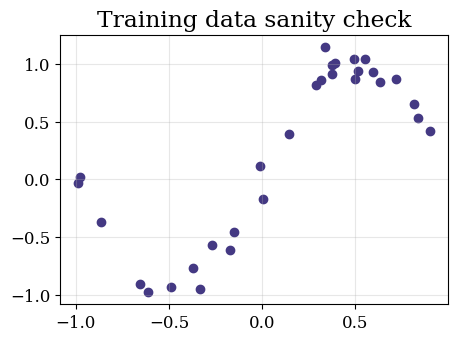

In [96]:
# =========================
# TRAINING DATA
# =========================

X_train, y_train = make_sine_data(
    n_points=30,
    noise=eps
)

# =========================
# TEST DATA
# =========================

X_test = torch.linspace(-1.0, 1.0, 50)
y_test = func(X_test)

# SANITY CHECK
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_train sample:", X_train[:5])
print("y_train sample:", y_train[:5])

import matplotlib.pyplot as plt

plt.scatter(X_train, y_train)
plt.title("Training data sanity check")
plt.show()

In [97]:
print(X_test[:10])

tensor([-1.0000, -0.9592, -0.9184, -0.8776, -0.8367, -0.7959, -0.7551, -0.7143,
        -0.6735, -0.6327])


Kernel params: 8
Initial kernel norm: 8.775613784790039
Kernel stats:
min: 0.00013075109745841473
max: 1.0
mean: 0.38792964816093445


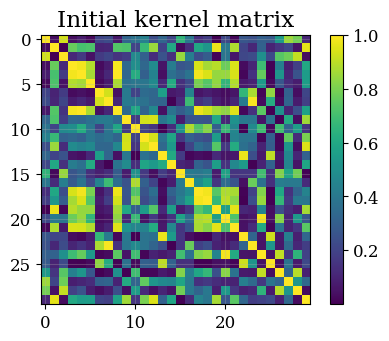

In [98]:
# =========================
# MODEL SETUP
# =========================

kernel = QuantumKernel(
    n_qubits=n_qubits,
    n_layers=n_layers,
    phi=phi
)

likelihood = gpytorch.likelihoods.GaussianLikelihood()

model = QGP(X_train, y_train, likelihood, kernel)


# SANITY CHECK
print("Kernel params:", kernel.n_params)
print("Initial kernel norm:", torch.norm(kernel.params).item())

with torch.no_grad():
    K = kernel(X_train, X_train).to_dense()

print("Kernel stats:")
print("min:", K.min().item())
print("max:", K.max().item())
print("mean:", K.mean().item())

import matplotlib.pyplot as plt

plt.imshow(K.detach().numpy())
plt.title("Initial kernel matrix")
plt.colorbar()
plt.show()

In [101]:
# =========================
# TRAINING
# =========================
import time
start_time = time.time()

losses, initial_params = train_model(
    model=model,
    likelihood=likelihood,
    kernel=kernel,
    X=X_train,
    y=y_train,
    lr=lr,
    epochs=epochs
)

runtime_sec = time.time() - start_time

Epoch   0 - Loss 1.2316
Epoch   1 - Loss 1.2310
Epoch   2 - Loss 1.2304
Epoch   3 - Loss 1.2297
Epoch   4 - Loss 1.2291
Epoch   5 - Loss 1.2284
Epoch   6 - Loss 1.2278
Epoch   7 - Loss 1.2271
Epoch   8 - Loss 1.2264
Epoch   9 - Loss 1.2258


Trained kernel stats:
min: 5.97964390181005e-05
max: 1.0
mean: 0.37642768025398254


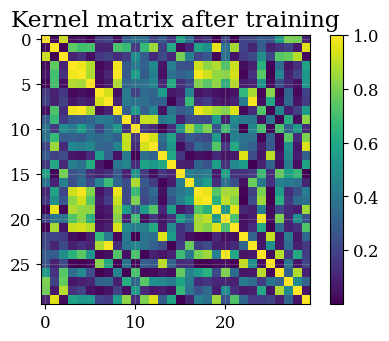

In [102]:
# =========================
# KERNEL AFTER TRAINING
# =========================
with torch.no_grad():
    K_trained = kernel(X_train, X_train).to_dense()

print("Trained kernel stats:")
print("min:", K_trained.min().item())
print("max:", K_trained.max().item())
print("mean:", K_trained.mean().item())

plt.imshow(K_trained.detach().numpy())
plt.title("Kernel matrix after training")
plt.colorbar()
plt.show()

In [103]:
# =========================
# EVALUATION
# =========================

pred_mean, pred_var, mse = evaluate_model(
    model=model,
    likelihood=likelihood,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test
)

In [104]:
print("MSE:", mse)

print("Prediction mean:")
print(pred_mean[:10])

print("Prediction variance:")
print(pred_var[:10])

MSE: 0.39857807755470276
Prediction mean:
tensor([-0.2105, -0.0879,  0.2636, -0.2509,  0.0783, -0.0193, -0.0682, -0.0699,
        -0.3843, -0.2457])
Prediction variance:
tensor([0.5890, 0.2833, 0.1628, 0.1352, 0.2683, 0.2638, 0.3973, 0.3136, 0.1575,
        0.1365])


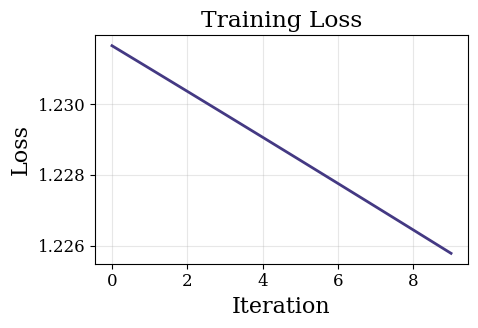

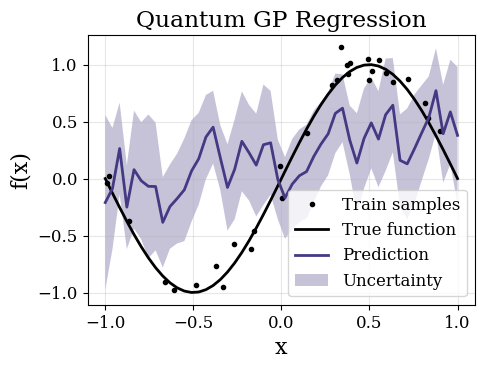

In [105]:
# =========================
# PLOTTING
# =========================

set_plot_style()

plot_loss(losses)

plot_regression(
    X_train, y_train,
    X_test, y_test,
    pred_mean, pred_var
)

In [112]:
# =========================
# LOGGING
# =========================

'''
from src.config import (
    SAVE_MODE,
    SCRATCH_FILE,
    FINAL_FILE
)
'''


PROJECT_DIR = "/content/drive/MyDrive/Praktikum/quantum_kernel_gpr_framework"

SAVE_MODE = "scratch"

SCRATCH_FILE = f"{PROJECT_DIR}/experiments/scratch.parquet"
FINAL_FILE = f"{PROJECT_DIR}/experiments/final.parquet"

row = build_experiment_row(
    n_qubits=n_qubits,
    n_layers=n_layers,
    kernel=kernel,
    lr=lr,
    epochs=epochs,
    N_train=X_train.shape[0],
    N_test=X_test.shape[0],
    noise_eps=eps,
    phi=phi,
    mse=mse,
    runtime_sec=runtime_sec,
    likelihood=likelihood,
    losses=losses,
    initial_params=initial_params,
    seed=SEED
)

print(type(row))
print(row.keys())

save_experiment(
    row=row,
    save_mode=SAVE_MODE,
    scratch_file=SCRATCH_FILE,
    final_file=FINAL_FILE
)

<class 'dict'>
dict_keys(['timestamp', 'n_qubits', 'n_layers', 'n_params', 'learning_rate', 'epochs', 'N_train', 'N_test', 'noise_eps', 'phi', 'mse', 'runtime_sec', 'likelihood_noise', 'final_loss', 'parameter_movement', 'seed'])
Saved to scratch database


In [116]:
%cd /content
!git clone https://github.com/finkalissa303/quantum-kernel-gpr-pennylane.git
%cd quantum-kernel-gpr-pennylane

/content
Cloning into 'quantum-kernel-gpr-pennylane'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 11 (delta 2), reused 7 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 1.02 MiB | 20.86 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/quantum-kernel-gpr-pennylane


In [ ]:
!cp -r /content/drive/MyDrive/Praktikum/quantum_kernel_gpr_framework/. .

In [115]:
!cp -r /content/drive/MyDrive/Praktikum/quantum_kernel_gpr_framework/*.py .

cp: cannot stat '/content/drive/MyDrive/Praktikum/quantum_kernel_gpr_framework/*.py': No such file or directory
